In previous work, I've imputed values to help normalize the target values more to help deal with the class imbalance issue. Becuase we know that our data is all null for the any value where impact actually takes place and that damage in our case is for completely damaged homes, I thought maybe it'd be an interesting experiment to look into weather or not we can take some of the storm data (not used in our model to prevent data leakage) to help normalize this data more

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, GridSearchCV, RepeatedKFold
from sklearn.ensemble import RandomForestRegressor,ExtraTreesRegressor, HistGradientBoostingRegressor, BaggingRegressor, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, root_mean_squared_error, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score, roc_curve,precision_score, recall_score
import seaborn as sns
import warnings
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import MinMaxScaler,StandardScaler
import networkx as nx
from itertools import product
import pickle
import lightgbm as lgb
import xgboost as xgb
from sklearn.dummy import DummyRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.exceptions import DataConversionWarning
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVR
import os 
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import copy
from rasterstats import zonal_stats
import geopandas as gpd
import numpy as np
import rasterio
import sys
import os 
from osgeo import ogr  
ogr.UseExceptions()
from datetime import datetime, timedelta
import warnings
import shapefile
import csv
from rasterio.crs import CRS
from shapely.geometry import shape
from shapely import wkt
from shapely.geometry import Point
from shapely.strtree import STRtree
from shapely.geometry import box
import psutil
import shutil
from pathlib import Path
import re
import json
import xarray as xr
plt.rcParams['font.family'] = 'Helvetica'
warnings.filterwarnings("ignore", message="X does not have valid feature names")
warnings.filterwarnings('ignore', category=DataConversionWarning)
%matplotlib inline

thesis_cmap_div = mcolors.LinearSegmentedColormap.from_list(
    "thesis_div",
    [
        '#F6511D',
        '#EAF2EF',
        '#097FC7',
    ]
)

plt.rcParams['font.family'] = 'Helvetica'

BACKGROUND_COLOR = '#EAF2EF'

%load_ext autoreload 
%autoreload 2

from helper_functions import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Read in the needed data: 

In [56]:
# read in the target file and filter to the columns we need for the model training
target_cols = ['typhoon_name', 'typhoon_year', 'grid_point_id','percent_houses_damaged','percent_houses_damaged_5years']
target = pd.read_csv('../data/target/new_model_training_dataset.csv')

In [60]:
target_impact = target[target['percent_houses_damaged'] > 0].drop(columns=['typhoon_name'])

target_corrs = target_impact.corr()['percent_houses_damaged'] 

target_corrs[abs(target_corrs) >= 0.1].sort_values(ascending=False)

percent_houses_damaged        1.000000
wind_speed                    0.438799
strong_roof_salvage_wall      0.234219
grid_point_id                 0.224060
salvaged_roof_salvage_wall    0.148721
rainfall_max_6h               0.132420
strong_roof_light_wall        0.131849
light_roof_salvage_wall       0.118719
water                         0.117031
with_coast                    0.111439
salvaged_roof_light_wall      0.104031
typhoon_year                 -0.103476
mean_elev                    -0.104354
strong_roof_strong_wall      -0.186478
track_distance               -0.198392
Name: percent_houses_damaged, dtype: float64

In [ ]:
# look at these columns and decide which ones I think are more important here,
# maybe look at the corr between the target and these variables to then decide 
# on the weighting

def create_blended_target(df_target, weight=0.3):
    df = df_target.copy()

    def minmax(s):
        return (s - s.min()) / (s.max() - s.min())

    # hazard features: weights from Spearman correlation with percent_houses_damaged
    wind_norm  = minmax(df['wind_speed'])           # corr: 0.44
    track_norm = 1 - minmax(df['track_distance'])   # corr: -0.20 (inverted)
    rain_norm  = minmax(df['rainfall_max_6h'])       # corr: 0.13

    # vulnerability composite: weights from Spearman correlation (all the vulnerability items)
    vuln_norm = minmax(
        df['strong_roof_salvage_wall']   * 0.234 +
        df['salvaged_roof_salvage_wall'] * 0.149 +
        df['strong_roof_light_wall']     * 0.132 +
        df['light_roof_salvage_wall']    * 0.119 +
        df['salvaged_roof_light_wall']   * 0.104
    )

    # protection term (e.g. negatively correlated features)
    protection_norm = minmax(
        df['strong_roof_strong_wall'] * 0.186 +
        df['mean_elev']               * 0.104
    )

    # correlation-weighted proxy
    proxy = (
        0.44 * wind_norm +
        0.20 * track_norm +
        0.15 * vuln_norm +
        0.13 * rain_norm
    ) * (1 - protection_norm * 0.15)

    # scale to same range as actual damage
    proxy_scaled = proxy * df['percent_houses_damaged'].max()

    print(f"Proxy zeros:  {(proxy_scaled == 0).mean()*100:.1f}%")
    print(f"Actual zeros: {(df['percent_houses_damaged'] == 0).mean()*100:.1f}%")
    print(f"Proxy mean:   {proxy_scaled.mean():.2f} vs actual mean: {df['percent_houses_damaged'].mean():.2f}")
    print(f"Proxy range:  {proxy_scaled.min():.2f} – {proxy_scaled.max():.2f}")

    df['target_blended'] = np.where(
        df['percent_houses_damaged'] > 0,
        (1 - weight) * df['percent_houses_damaged'] + weight * proxy_scaled,
        weight * proxy_scaled
    )

    return df

In [ ]:
# df_blended = create_blended_target(df_target, weight=0.3)
storm_names = [
    'bopha_0',
    'utor_1',
    'trami_2',
    'usagi_3',
    'nari_4',
    'krosa_5',
    'haiyan_6',
    'lingling_7',
    'sarika_18',
    'haima_19',
    'nock_ten_20',
    'mangkhut_21'
]

# read in the target file and filter to the columns we need for the model training
target_cols = ['typhoon_name', 'typhoon_year', 'grid_point_id','percent_houses_damaged','percent_houses_damaged_5years']
target = pd.read_csv('../data/target/new_model_training_dataset.csv')

dfs = []
for storm in storm_names:
    df = pd.read_csv(f'../data/upscale_data_final/{storm.split("_")[0]}/grided_data_for_{storm}_expanded.csv')
    dfs.append(df)
result = pd.concat(dfs)

for weight in [0.1, 0.2, 0.3]:
    # get out new smoothed df/bended target
    df_blended = create_blended_target(target, weight=weight)
    
    target_blended = df_blended[['typhoon_name', 'typhoon_year', 'grid_point_id',
                                  'percent_houses_damaged', 'percent_houses_damaged_5years', 'target_blended']]
    
    final_df = pd.merge(target_blended, result, how="inner", on=["typhoon_name", "typhoon_year", "grid_point_id"])
    final_df.to_csv(f'../data/target/synthetic/model_training_data_final_weight_{weight}_synth.csv', index=False)
    
    print(f"\nweight = {weight} saved — target_blended stats:")
    print(final_df['target_blended'].describe())

Proxy zeros:  0.0%
Actual zeros: 91.6%
Proxy mean:   62.08 vs actual mean: 0.30
Proxy range:  8.11 – 195.03


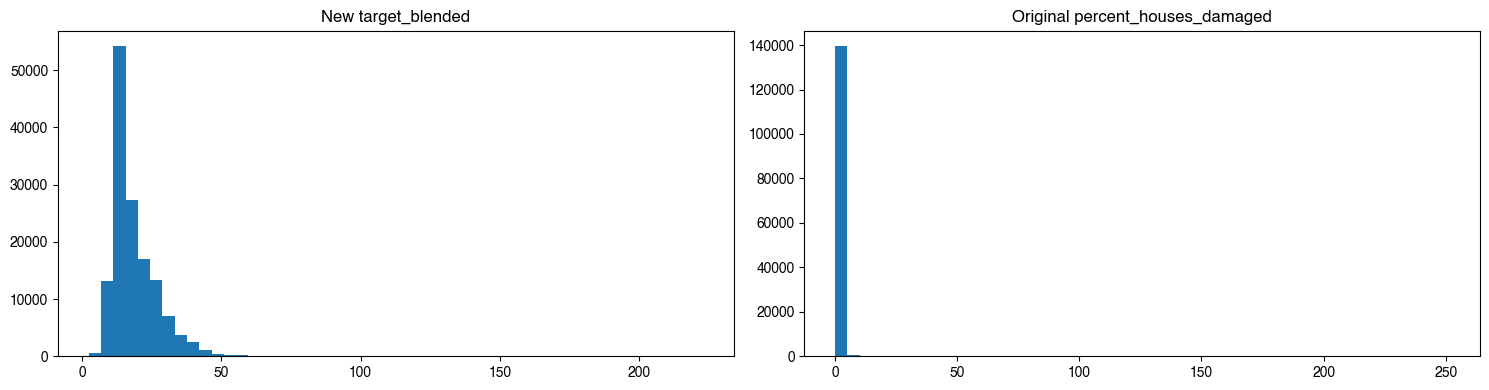

In [ ]:
# new approach
df_new = create_blended_target(target, weight=0.3)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].hist(df_new['target_blended'], bins=50)
axes[0].set_title('New target_blended')

axes[1].hist(target['percent_houses_damaged'], bins=50)
axes[1].set_title('Original percent_houses_damaged')

plt.tight_layout()
plt.show()

Since we have the functions to do this, we're going to quick run baselines to see how these compare:

In [ ]:
df_01 = pd.read_csv('../data/target/synthetic/model_training_data_final_weight_0.1_synth.csv')
target_cols = ['percent_houses_damaged','percent_houses_damaged_5years','target_blended']
main_target = 'target_blended'
X_train_01, X_test_01, y_train_01, y_test_01 = clean_and_split_data(df_01, target_cols, main_target, filling_method='complex', remove_corr_cols=False, thresh=0.75)

X_train_01.drop(columns=['grid_point_id'],inplace=True)
X_test_01.drop(columns=['grid_point_id'],inplace=True)

print("for LGBM:")
lgb_model = lgb.LGBMRegressor(random_state=42, n_jobs=-1,verbose=0);
lgb_model.fit(X_train_01, y_train_01)

scores = cross_val_score(lgb_model, X_train_01, y_train_01, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_lgb = lgb_model.predict(X_test_01)
test_r2_lgb = r2_score(y_test_01, y_pred_lgb)
print(f"Test Set R²: {test_r2_lgb:.4f}")

print("for HistGradientBoostingRegressor:")
hgbr_model = HistGradientBoostingRegressor(random_state=42,verbose=0)
hgbr_model.fit(X_train_01, y_train_01)

scores = cross_val_score(hgbr_model, X_train_01, y_train_01, cv=5, scoring='r2',verbose=0)
print(f"mean CV score: {scores.mean():.4f}")

y_pred_hgbr = hgbr_model.predict(X_test_01)
test_r2_hgbr = r2_score(y_test_01, y_pred_hgbr)
print(f"Test Set R²: {test_r2_hgbr:.4f}")

for LGBM:
mean CV score: 0.2656
Test Set R²: 0.2735
for HistGradientBoostingRegressor:
mean CV score: 0.2612
Test Set R²: 0.2526


In [ ]:
df_01 = pd.read_csv('../data/target/synthetic/model_training_data_final_weight_0.2_synth.csv')
target_cols = ['percent_houses_damaged','percent_houses_damaged_5years','target_blended']
main_target = 'target_blended'
X_train_01, X_test_01, y_train_01, y_test_01 = clean_and_split_data(df_01, target_cols, main_target, filling_method='complex', remove_corr_cols=False, thresh=0.75)

X_train_01.drop(columns=['grid_point_id'],inplace=True)
X_test_01.drop(columns=['grid_point_id'],inplace=True)

print("for LGBM:")
lgb_model = lgb.LGBMRegressor(random_state=42, n_jobs=-1,verbose=0);
lgb_model.fit(X_train_01, y_train_01)

scores = cross_val_score(lgb_model, X_train_01, y_train_01, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_lgb = lgb_model.predict(X_test_01)
test_r2_lgb = r2_score(y_test_01, y_pred_lgb)
print(f"Test Set R²: {test_r2_lgb:.4f}")

print("for HistGradientBoostingRegressor:")
hgbr_model = HistGradientBoostingRegressor(random_state=42,verbose=0)
hgbr_model.fit(X_train_01, y_train_01)

scores = cross_val_score(hgbr_model, X_train_01, y_train_01, cv=5, scoring='r2',verbose=0)
print(f"mean CV score: {scores.mean():.4f}")

y_pred_hgbr = hgbr_model.predict(X_test_01)
test_r2_hgbr = r2_score(y_test_01, y_pred_hgbr)
print(f"Test Set R²: {test_r2_hgbr:.4f}")

print("for XGBRegressor:")
xgb_b_model = xgb.XGBRegressor(random_state=42)
xgb_b_model.fit(X_train_01, y_train_01)

scores = cross_val_score(xgb_b_model,  X_train_01, y_train_01, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_xgbb = xgb_b_model.predict(X_test_01)
test_r2_xgbb = r2_score(y_test_01, y_pred_xgbb)
print(f"Test Set R²: {test_r2_xgbb:.4f}")

# for LGBM:
# mean CV score: 0.3917
# Test Set R²: 0.3954
# for HistGradientBoostingRegressor:
# mean CV score: 0.3904
# Test Set R²: 0.3923

for LGBM:
mean CV score: 0.3917
Test Set R²: 0.3954
for HistGradientBoostingRegressor:
mean CV score: 0.3904
Test Set R²: 0.3923


In [ ]:
df_01 = pd.read_csv('../data/target/synthetic/model_training_data_final_weight_0.3_synth.csv')
target_cols = ['percent_houses_damaged','percent_houses_damaged_5years','target_blended']
main_target = 'target_blended'
X_train_01, X_test_01, y_train_01, y_test_01 = clean_and_split_data(df_01, target_cols, main_target, filling_method='complex', remove_corr_cols=False, thresh=0.75)

X_train_01.drop(columns=['grid_point_id'],inplace=True)
X_test_01.drop(columns=['grid_point_id'],inplace=True)

print("for LGBM:")
lgb_model = lgb.LGBMRegressor(random_state=42, n_jobs=-1,verbose=0);
lgb_model.fit(X_train_01, y_train_01)

scores = cross_val_score(lgb_model, X_train_01, y_train_01, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")
print_consistent_results(lgb_model, X_train_01, y_train_01, X_test_01, y_test_01, cv=5)

y_pred_lgb = lgb_model.predict(X_test_01)
test_r2_lgb = r2_score(y_test_01, y_pred_lgb)
print(f"Test Set R²: {test_r2_lgb:.4f}")

print("for HistGradientBoostingRegressor:")
hgbr_model = HistGradientBoostingRegressor(random_state=42,verbose=0)
hgbr_model.fit(X_train_01, y_train_01)

scores = cross_val_score(hgbr_model, X_train_01, y_train_01, cv=5, scoring='r2',verbose=0)
print(f"mean CV score: {scores.mean():.4f}")

y_pred_hgbr = hgbr_model.predict(X_test_01)
test_r2_hgbr = r2_score(y_test_01, y_pred_hgbr)
print(f"Test Set R²: {test_r2_hgbr:.4f}")

print_consistent_results(hgbr_model, X_train_01, y_train_01, X_test_01, y_test_01, cv=5)

print("for XGBRegressor:")
xgb_b_model = xgb.XGBRegressor(random_state=42)
xgb_b_model.fit(X_train_01, y_train_01)

scores = cross_val_score(xgb_b_model,  X_train_01, y_train_01, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_xgbb = xgb_b_model.predict(X_test_01)
test_r2_xgbb = r2_score(y_test_01, y_pred_xgbb)
print(f"Test Set R²: {test_r2_xgbb:.4f}")

print_consistent_results(xgb_b_model, X_train_01, y_train_01, X_test_01, y_test_01, cv=5)

for LGBM:
mean CV score: 0.4607
Cross-validation R²:   0.4607 ± 0.0150
Cross-validation RMSE: 7.8748 ± 0.3111
Test Set R²:           0.4629
Test Set RMSE:         8.0271
Test Set R²: 0.4629
for HistGradientBoostingRegressor:
mean CV score: 0.4588
Test Set R²: 0.4641
Cross-validation R²:   0.4588 ± 0.0148
Cross-validation RMSE: 7.8884 ± 0.2976
Test Set R²:           0.4641
Test Set RMSE:         8.0185
for XGBRegressor:
mean CV score: 0.4470
Test Set R²: 0.4495
Cross-validation R²:   0.4470 ± 0.0147
Cross-validation RMSE: 7.9733 ± 0.2895
Test Set R²:           0.4495
Test Set RMSE:         8.1264


In [223]:
# X_train_01, X_test_01, y_train_01, y_test_01
n_repeats = 2

param_grid_lgbm = {
    "n_estimators":      [100, 200, 300],
    "max_depth":         [3, 5, 7],        # remove -1, force depth limit
    "learning_rate":     [0.01, 0.05, 0.1],
    "num_leaves":        [15, 31, 63],     # add smaller option
    "min_child_samples": [20, 50, 100],    # increase minimum — was too low at 10
    "reg_lambda":        [0.1, 1.0, 10.0], # push higher regularisation
    "reg_alpha":         [0.0, 0.1, 1.0],  # add L1 regularisation
    "subsample":         [0.6, 0.8, 1.0],  # row subsampling
    "colsample_bytree":  [0.6, 0.8, 1.0],  # feature subsampling per tree
    "min_gain_to_split": [0.0, 0.1, 1.0],  # minimum gain required to split
}

# q75 = y_train_01.quantile(0.75)
# tail_mask = y_train_01 > q75

# X_tail = X_train_01[tail_mask]
# y_tail  = y_train_01[tail_mask].squeeze()

# noise_X   = 0.01
# noise_y   = 0.01 * y_train_01.std()

# X_augmented = pd.concat([X_tail + np.random.normal(0, noise_X, X_tail.shape) for _ in range(n_repeats)])
# y_augmented = pd.concat([y_tail + np.random.normal(0, noise_y, y_tail.shape) for _ in range(n_repeats)])

# # clip y to prevent negative values
# y_augmented = y_augmented.clip(lower=0)

# X_train_over = pd.concat([X_train_01, X_augmented])
# y_train_over = pd.concat([y_train_01, y_augmented]).squeeze()  # ← force to Series

# # also make sure y_test is a Series
# y_test_01 = y_test_01.squeeze()

best_config_lgbm_01, best_X_tr_lgbm_01, best_X_te_lgbm_01, best_y_tr_lgbm_01, best_y_te_lgbm_01, model_01 = auto_optimize_model(
    lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    X_train_01,
    X_test_01,
    y_train_01,
    y_test_01,
    do_gridsearch= True,
    param_grid   = param_grid_lgbm,
    cv=5,
    name_add='synthetic_data_03_final'
)

STEP 1: Baseline
  CV R²: 0.4607 | Test R²: 0.4629 | Gap: 0.0022

STEP 2: Feature selection
Large group (18 features) → selected: prop_not_enough_data_impact_dur_avail30
Large group (9 features) → selected: mean_available
Large group (6 features) → selected: prob_aff
Large group (8 features) → selected: mean_impact_dur_avail30_isna
Subsampled to 200 combinations
Searching 200 combinations from 8 small groups...
Best exhaustive combo score: 0.4604

Final feature count: 20 from original 67

[Feature selection] ✗ rejected (20 cols from 67)
  CV R²: 0.4604 | Test R²: 0.4616 | Gap: 0.0012

STEP 3: Feature scaling

[Scaling (StandardScaler)] ✗ rejected 
  CV R²: 0.4610 | Test R²: 0.4599 | Gap: 0.0012

[Scaling (MinMaxScaler)] ✓ accepted 
  CV R²: 0.4598 | Test R²: 0.4687 | Gap: 0.0089

STEP 4: Log transform target

[Log transform target] ✗ rejected 
  CV R²: 0.5639 | Test R²: 0.4381 | Gap: 0.1258

FINAL SUMMARY
  Model name:         lgbm_minmax
  Best Test R²:       0.4687
  Best Gap:       

In [224]:
print_consistent_results(model_01, X_train_01, y_train_01, X_test_01, y_test_01, cv=5)

Cross-validation R²:   0.4598 ± 0.0132
Cross-validation RMSE: 7.8814 ± 0.2984
Test Set R²:           0.4687
Test Set RMSE:         7.9835


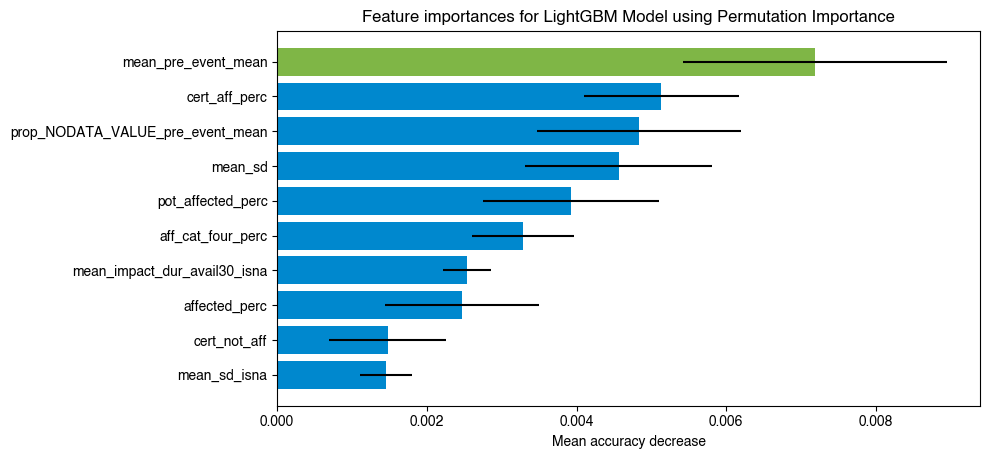

In [209]:
print_feature_importance_pm(
    lgb_model,
    X_test_01,          
    y_test_01,          
    X_test_01.columns,
    "LightGBM",
    '#0088ce', 
    '#7fb646'
)

checking baselines with only the urban cover to see if we have a problem with the coarseness of our cell sizes, really this data should preform better than the full suite of data:

In [ ]:
# df_blended = create_blended_target(df_target, weight=0.3)
storm_names = [
    'bopha_0',
    'utor_1',
    'trami_2',
    'usagi_3',
    'nari_4',
    'krosa_5',
    'haiyan_6',
    'lingling_7',
    'sarika_18',
    'haima_19',
    'nock_ten_20',
    'mangkhut_21'
]

dfs = []

    # for clarity, storm name list with number included like: `bopha_0`
for storm in storm_names:
    df = pd.read_csv(f'../data/upscale_data_final_urban/{storm.split("_")[0]}/grided_data_for_{storm}_expanded_urban.csv')
    # df["perc_available_upscaled_new"]
    dfs.append(df)

result= pd.concat(dfs)

for weight in 0.1, 0.2, 0.3:
    df_blended = create_blended_target(target, weight=weight)
    # fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    # axes[0].hist(target['percent_houses_damaged'], bins=50)
    # axes[0].set_title('Original')
    # axes[1].hist(df_blended['target_blended'], bins=50)
    # axes[1].set_title(f'Blended (weight=0.3)')
    # plt.show()

    # print(f"Original zeros: {(target['percent_houses_damaged'] == 0).mean()*100:.1f}%")
    # print(f"Blended zeros:  {(df_blended['target_blended'] == 0).mean()*100:.1f}%")
    target_blended_cols = ['typhoon_name', 'typhoon_year', 'grid_point_id','percent_houses_damaged','percent_houses_damaged_5years','target_blended']
    target_blended = df_blended[target_blended_cols]

    final_df = pd.merge(target_blended, result, how="inner", on=["typhoon_name", "typhoon_year", "grid_point_id"])

    final_df.to_csv(f'../data/target/synthetic/model_training_data_final_weight_{weight}_synth_urban.csv', index=False)
    

Proxy zeros:  0.0%
Actual zeros: 91.6%
Proxy mean:   62.08 vs actual mean: 0.30
Proxy range:  8.11 – 195.03
Proxy zeros:  0.0%
Actual zeros: 91.6%
Proxy mean:   62.08 vs actual mean: 0.30
Proxy range:  8.11 – 195.03
Proxy zeros:  0.0%
Actual zeros: 91.6%
Proxy mean:   62.08 vs actual mean: 0.30
Proxy range:  8.11 – 195.03


In [ ]:
df_02 = pd.read_csv('../data/target/synthetic/model_training_data_final_weight_0.3_synth_urban.csv')
target_cols = ['percent_houses_damaged','percent_houses_damaged_5years','target_blended']
main_target = 'target_blended'
X_train_02, X_test_02, y_train_02, y_test_02 = clean_and_split_data(df_02, target_cols, main_target, filling_method='complex', remove_corr_cols=False, thresh=0.75)

X_train_02.drop(columns=['grid_point_id'],inplace=True)
X_test_02.drop(columns=['grid_point_id'],inplace=True)

print("for LGBM:")
lgb_model = lgb.LGBMRegressor(random_state=42, n_jobs=-1,verbose=0);
lgb_model.fit(X_train_02, y_train_02)

scores = cross_val_score(lgb_model, X_train_02, y_train_02, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_lgb = lgb_model.predict(X_test_02)
test_r2_lgb = r2_score(y_test_02, y_pred_lgb)
print(f"Test Set R²: {test_r2_lgb:.4f}")

print("for HistGradientBoostingRegressor:")
hgbr_model = HistGradientBoostingRegressor(random_state=42,verbose=0)
hgbr_model.fit(X_train_02, y_train_02)

scores = cross_val_score(hgbr_model, X_train_02, y_train_02, cv=5, scoring='r2',verbose=0)
print(f"mean CV score: {scores.mean():.4f}")

y_pred_hgbr = hgbr_model.predict(X_test_02)
test_r2_hgbr = r2_score(y_test_02, y_pred_hgbr)
print(f"Test Set R²: {test_r2_hgbr:.4f}")

for LGBM:
mean CV score: 0.2457
Test Set R²: 0.2400
for HistGradientBoostingRegressor:
mean CV score: 0.2444
Test Set R²: 0.2357


Run the pipeline that we have in the helper functions to see if we can improve this model:

In [ ]:
# X_train_01, X_test_01, y_train_01, y_test_01
n_repeats = 2

param_grid_lgbm = {
    "n_estimators":      [100, 200, 300],
    "max_depth":         [3, 5, 7],        # remove -1, force depth limit
    "learning_rate":     [0.01, 0.05, 0.1],
    "num_leaves":        [15, 31, 63],     # add smaller option
    "min_child_samples": [20, 50, 100],    # increase minimum — was too low at 10
    "reg_lambda":        [0.1, 1.0, 10.0], # push higher regularisation
    "reg_alpha":         [0.0, 0.1, 1.0],  # add L1 regularisation
    "subsample":         [0.6, 0.8, 1.0],  # row subsampling
    "colsample_bytree":  [0.6, 0.8, 1.0],  # feature subsampling per tree
    "min_gain_to_split": [0.0, 0.1, 1.0],  # minimum gain required to split
}

# q75 = y_train_01.quantile(0.75)
# tail_mask = y_train_01 > q75

# X_tail = X_train_01[tail_mask]
# y_tail  = y_train_01[tail_mask].squeeze()

# noise_X   = 0.01
# noise_y   = 0.01 * y_train_01.std()

# X_augmented = pd.concat([X_tail + np.random.normal(0, noise_X, X_tail.shape) for _ in range(n_repeats)])
# y_augmented = pd.concat([y_tail + np.random.normal(0, noise_y, y_tail.shape) for _ in range(n_repeats)])

# # clip y to prevent negative values
# y_augmented = y_augmented.clip(lower=0)

# X_train_over = pd.concat([X_train_01, X_augmented])
# y_train_over = pd.concat([y_train_01, y_augmented]).squeeze()  # ← force to Series

# # also make sure y_test is a Series
# y_test_01 = y_test_01.squeeze()

best_config_lgbm_, best_X_tr_lgbm_03, best_X_te_lgbm_03, best_y_tr_lgbm_03, best_y_te_lgbm_03, model = auto_optimize_model(
    lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    X_train_02,
    X_test_02,
    y_train_02,
    y_test_02,
    do_gridsearch= True,
    param_grid   = param_grid_lgbm,
    cv=5,
    name_add='synthetic_data_03_urban'
)

# ============================================================
# FINAL SUMMARY
# ============================================================
#   Model name:         lgbm_tuned
#   Best Test R²:       0.2441
#   Best Gap:           0.0071
#   Feature selection:  False
#   Scaling:            None
#   Log transform:      False
#   Gridsearch:         True
#   Best params:        {'subsample': 0.6, 'reg_lambda': 0.1, 'reg_alpha': 0.0, 'num_leaves': 63, 'n_estimators': 300, 'min_gain_to_split': 0.1, 'min_child_samples': 20, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.6}
#   Final feature count:60
#   Saved to:           ../models/lgbm_tuned_synthetic_data_03_urban.pkl

In [225]:
print_consistent_results(model, X_train_02, y_train_02, X_test_02, y_test_02, cv=5)

# Cross-validation R²:   0.2512 ± 0.0122
# Cross-validation RMSE: 8.9023 ± 0.2475
# Test Set R²:           0.2441
# Test Set RMSE:         8.8480

Cross-validation R²:   0.2512 ± 0.0122
Cross-validation RMSE: 8.9023 ± 0.2475
Test Set R²:           0.2441
Test Set RMSE:         8.8480


In [226]:
dummy = DummyRegressor(strategy='median')

dummy_r2 = cross_val_score(dummy, X_train_01, y_train_01, scoring='r2', cv=5)
print(f"Baseline R²: {dummy_r2.mean():.4f}")

# Also check on test set
dummy.fit(X_train_01, y_train_01)
y_pred_dummy = dummy.predict(X_test_01)
print(f"Baseline Test R²: {r2_score(y_test_01, y_pred_dummy):.4f}")

print_consistent_results(dummy, X_train_01, y_train_01, X_test_01, y_test_01, cv=5)

Baseline R²: -0.1174
Baseline Test R²: -0.1266
Cross-validation R²:   -0.1174 ± 0.0066
Cross-validation RMSE: 11.3346 ± 0.3755
Test Set R²:           -0.1266
Test Set RMSE:         11.6254


In [156]:
df_for_corr = df_01[df_01.columns[5:]]

corr_new_target = df_for_corr.drop(columns=['target_blended']).corrwith(df_for_corr['target_blended'], method='spearman').to_frame(name='Spearman Correlation').dropna()
corr_new_target = corr_new_target[abs(corr_new_target) > 0.14].dropna()
corr_new_target

/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/pandas/core/nanops.py:1661: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


,Spearman Correlation
mean_available,0.217412
median_available,0.169569
prop_NODATA_VALUE_DPmax,-0.148280
mean_impact_dur_pers_avail30,0.204809
median_impact_dur_pers_avail30,0.142572
median_recov_dur_avail50,0.149010
mean_recov_dur_avail30,0.254043
median_recov_dur_avail30,0.257238
mean_recov_dur_pers_avail50,0.191947
median_recov_dur_pers_avail50,0.256221


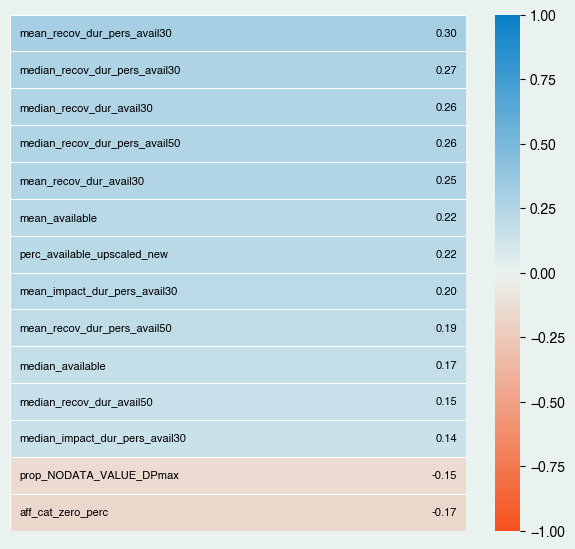

In [173]:
# look at the corrlation heat plot similar to what we had in the other models
BACKGROUND_COLOR = '#eaf2ef'
plt.rcParams['font.family'] = 'Helvetica'

# prep data
corrs_to_plot = corr_new_target.sort_values(by="Spearman Correlation",ascending=False).drop('target_blended', errors='ignore')
nan_mask = corrs_to_plot.isna()

plot_df = corrs_to_plot.fillna(np.nan)

cmap_with_grey = thesis_cmap_div
cmap_with_grey.set_bad(color='lightgrey')

fig, ax = plt.subplots(figsize=(6, len(corrs_to_plot) * 0.4), facecolor=BACKGROUND_COLOR)

sns.heatmap(
    plot_df.where(~nan_mask.values.reshape(-1, 1)),
    annot=False,
    cmap=cmap_with_grey,
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='white',
    xticklabels=False,
    yticklabels=False,
    ax=ax,
)

for i, col in enumerate(corrs_to_plot.index):
    val = corrs_to_plot.loc[col].values[0]
    is_nan = pd.isna(val)
    text_color = 'white' if abs(val) > 0.6 else 'black'
    val_str = f'{val:.2f}'
    ax.text(0.02, i + 0.5, col, ha='left', va='center', fontsize=8, color=text_color, zorder=3)
    ax.text(0.98, i + 0.5, val_str, ha='right', va='center', fontsize=8, fontweight='bold', color=text_color, zorder=3)

ax.set_facecolor(BACKGROUND_COLOR)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

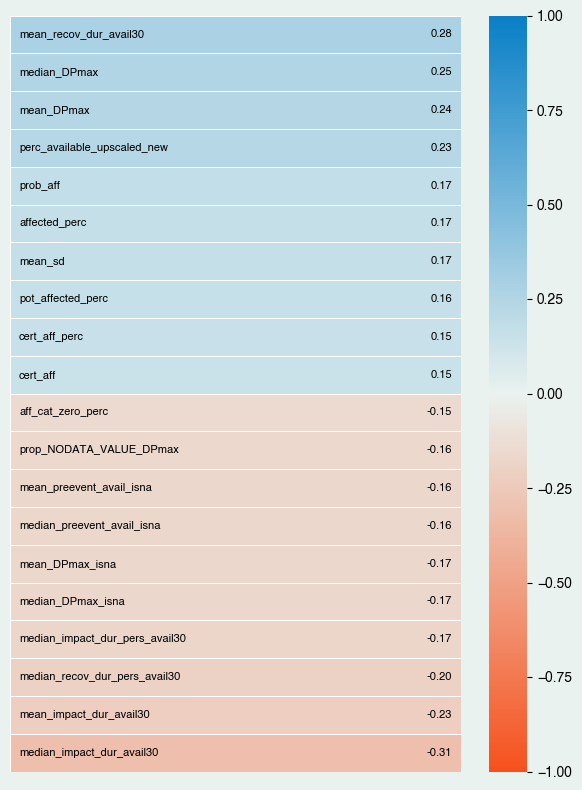

In [177]:
X_train_01, X_test_01, y_train_01, y_test_01

X_filled = pd.concat([X_train_01,X_test_01])
y_filled = pd.concat([y_train_01, y_test_01])

df_filled = pd.concat([X_filled, y_filled], axis=1)


df_for_corr_filled = df_filled[df_filled.columns[5:]]

corr_new_target = df_for_corr_filled.drop(columns=['target_blended']).corrwith(df_for_corr_filled['target_blended'], method='spearman').to_frame(name='Spearman Correlation').dropna()
corr_new_target = corr_new_target[abs(corr_new_target) > 0.14].dropna()

# look at the corrlation heat plot similar to what we had in the other models
BACKGROUND_COLOR = '#eaf2ef'
plt.rcParams['font.family'] = 'Helvetica'

# prep data
corrs_to_plot = corr_new_target.sort_values(by="Spearman Correlation",ascending=False).drop('target_blended', errors='ignore')
nan_mask = corrs_to_plot.isna()

plot_df = corrs_to_plot.fillna(np.nan)

cmap_with_grey = thesis_cmap_div
cmap_with_grey.set_bad(color='lightgrey')

fig, ax = plt.subplots(figsize=(6, len(corrs_to_plot) * 0.4), facecolor=BACKGROUND_COLOR)

sns.heatmap(
    plot_df.where(~nan_mask.values.reshape(-1, 1)),
    annot=False,
    cmap=cmap_with_grey,
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='white',
    xticklabels=False,
    yticklabels=False,
    ax=ax,
)

for i, col in enumerate(corrs_to_plot.index):
    val = corrs_to_plot.loc[col].values[0]
    is_nan = pd.isna(val)
    text_color = 'white' if abs(val) > 0.6 else 'black'
    val_str = f'{val:.2f}'
    ax.text(0.02, i + 0.5, col, ha='left', va='center', fontsize=8, color=text_color, zorder=3)
    ax.text(0.98, i + 0.5, val_str, ha='right', va='center', fontsize=8, fontweight='bold', color=text_color, zorder=3)

ax.set_facecolor(BACKGROUND_COLOR)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

Now to print out the consistent results:

In [178]:
print_consistent_results(model, best_X_tr_lgbm_03, best_y_tr_lgbm_03, best_X_te_lgbm_03, best_y_te_lgbm_03, cv=5)

Cross-validation R²:   0.4598 ± 0.0132
Cross-validation RMSE: 7.8814 ± 0.2984
Test Set R²:           0.4687
Test Set RMSE:         7.9835


In [179]:
best_X_tr_lgbm_03.shape

(24448, 67)

Now to get the residual plots for the results here:

In [ ]:
# df_01 = pd.read_csv('../data/target/synthetic/model_training_data_final_weight_0.3_synth.csv')
# with open('../models/lgbm_minmax_synthetic_data_03_final.pkl', 'rb') as f:
#     lgb_model_f = pickle.load(f)

# target_cols = ['percent_houses_damaged','percent_houses_damaged_5years','target_blended']
# main_target = 'target_blended'
# X_train, X_test, y_train, y_test = clean_and_split_data(df_01, target_cols, main_target, filling_method='complex', remove_corr_cols=False,thresh=0.75)
cols = lgb_model_f.feature_names_in_.tolist()
cols.append('grid_point_id')

X_train = X_train[cols]
X_test = X_test[cols]

import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, root_mean_squared_error

X_train_wo_grid = X_train.drop(columns=['grid_point_id'])
X_test_wo_grid  = X_test.drop(columns=['grid_point_id'])

# Compute residuals
results_data  = X_test_wo_grid.copy()
results_data['y_pred'] = lgb_model_f.predict(X_test_wo_grid)
results_data['residuals'] = y_test.values - lgb_model_f.predict(X_test_wo_grid)
results_data['y_actual'] = y_test.values

# Add grid_point_id from X_test_f using shared index
results_data['grid_point_id'] = X_test['grid_point_id'].values

# Load grid shapefile
gdf = gpd.read_file('../data/shape_files/clipped_grid_for_analysis.gpkg')
gdf.rename(columns={'id': 'grid_point_id'}, inplace=True)

# Merge with geometry\
results_data_gdf = gdf.merge(results_data, on='grid_point_id', how='right')

print(f"results:   {len(results_data_gdf)} rows")

# training data
train_data = X_train_wo_grid.copy()
train_data['y_pred'] = lgb_model_f.predict(X_train_wo_grid)
train_data['residuals'] = y_train.values - lgb_model_f.predict(X_train_wo_grid)
train_data['y_actual'] = y_train.values
train_data['split'] = 'train'
results_data['split'] = 'test'

train_data['grid_point_id'] = X_train['grid_point_id'].values

full = pd.concat([train_data, results_data])
full_gdf = gdf.merge(full, on='grid_point_id', how='right')

results:   8150 rows


In [242]:
[i for i in lgb_model.feature_names_in_.tolist() if i not in X_test_wo_grid.columns.to_list()]

# X_test_wo_grid.columns.to_list()

['prop_NODATA_VALUE_aff',
 'prop_NODATA_VALUE_available',
 'prop_NODATA_VALUE_sd',
 'no_aff_data',
 'majority_aff_isna',
 'minority_aff_isna',
 'mean_available_isna',
 'median_available_isna',
 'perc_available_upscaled_new_isna']

In [217]:
grid_point_avail_across_storm =  full_gdf.groupby('grid_point_id')['perc_available_upscaled_new'].mean()
grid_point_residuals_across_storm =  full_gdf.groupby('grid_point_id')['residuals'].mean()
grid_point_ground_truth_across_storm =  full_gdf.groupby('grid_point_id')['y_actual'].mean()

#rest the column name to make easier to join and reset the index for merging
grid_point_avail_across_storm = grid_point_avail_across_storm.reset_index()
grid_point_residuals_across_storm = grid_point_residuals_across_storm.reset_index()
grid_point_ground_truth_across_storm = grid_point_ground_truth_across_storm.reset_index()

#join the geodata to these median values for plotting
grid_point_avail_across_storm_gdf = gdf.merge(grid_point_avail_across_storm, on='grid_point_id', how='right')
grid_point_residuals_across_storm_gdf = gdf.merge(grid_point_residuals_across_storm, on='grid_point_id', how='right')
grid_point_ground_truth_across_storm_gdf = gdf.merge(grid_point_ground_truth_across_storm, on='grid_point_id', how='right')

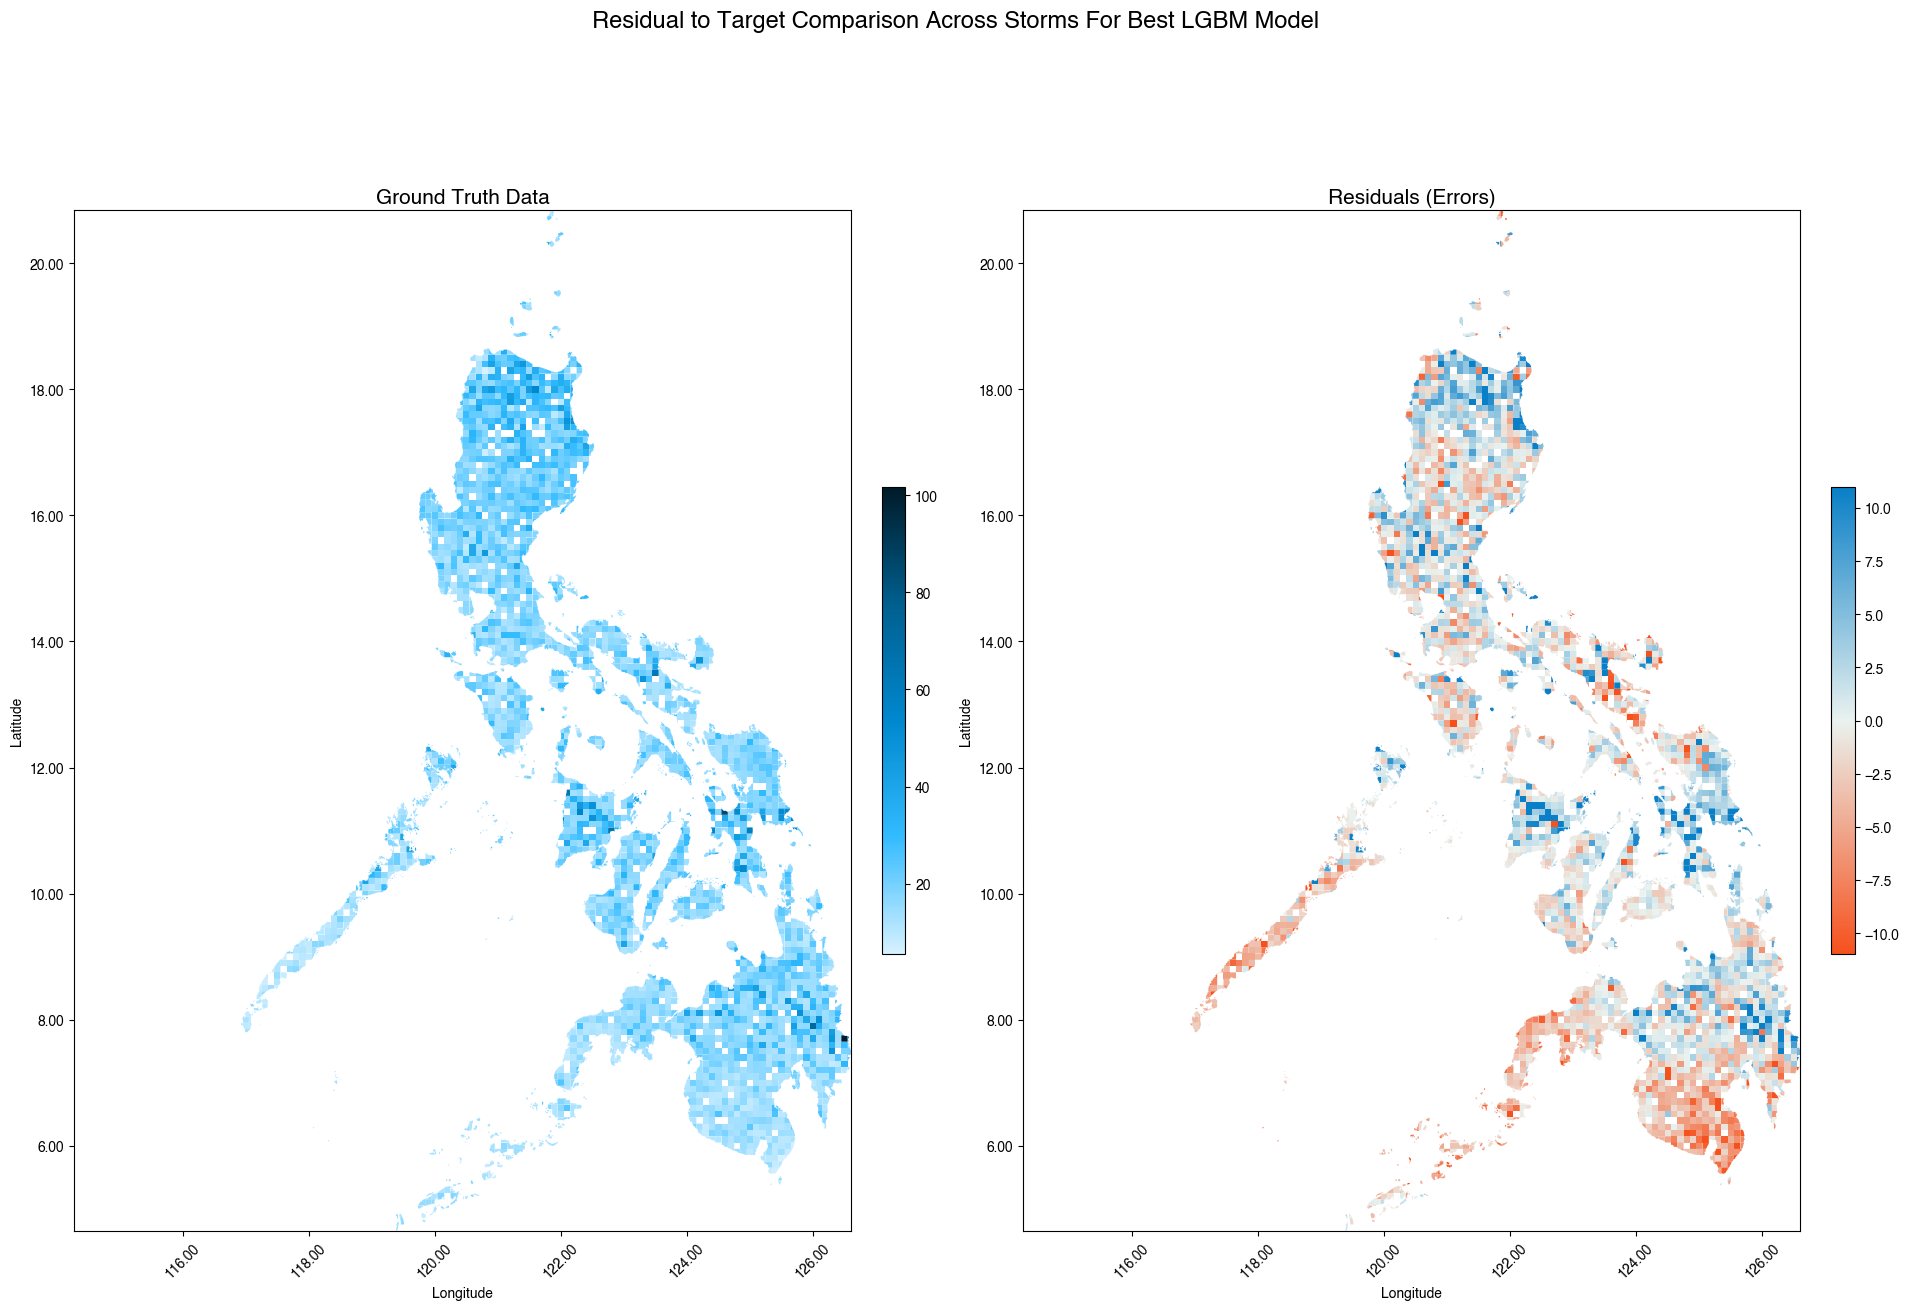

In [218]:
cmap1 = mcolors.LinearSegmentedColormap.from_list(
    "my_cmap",
    ['#0088ce', '#7fb646', '#ee964b', '#87677b', '#26413c']
)

same_scale_color_map = mcolors.LinearSegmentedColormap.from_list(
    "my_cmap",
    ['#D6F1FF', '#33BBFF', '#0088ce', '#005F8F', '#001B29']
)

fig, axes = plot_choropleth_grid(
    [grid_point_ground_truth_across_storm_gdf,grid_point_residuals_across_storm_gdf],
    columns=['y_actual','residuals'],
    titles=["Ground Truth Data","Residuals (Errors)",],
    cmaps=[same_scale_color_map,thesis_cmap_div],
    suptitle="Residual to Target Comparison Across Storms For Best LGBM Model",
    missing_color='white',
    shared_scale=False, 
    diverging = [False, True],
    figsize = (19, 14),  # all panels use the same min/max
)
plt.show()

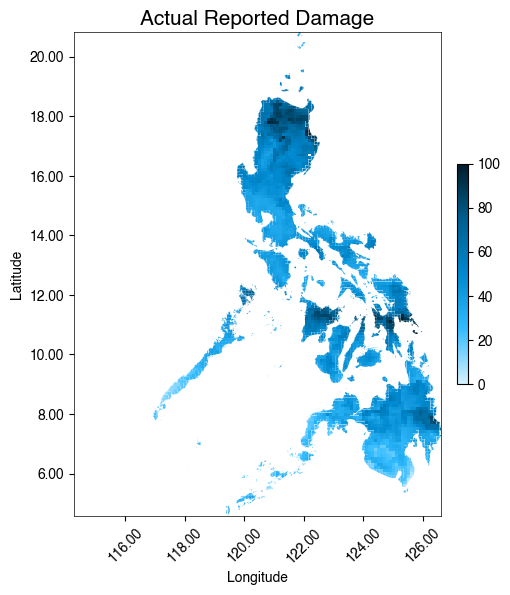

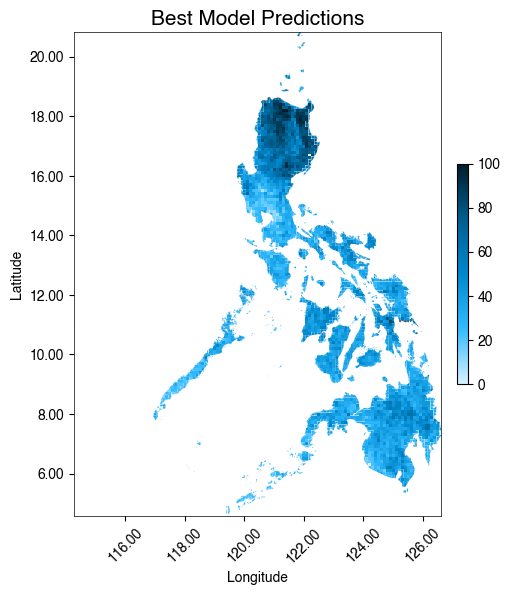

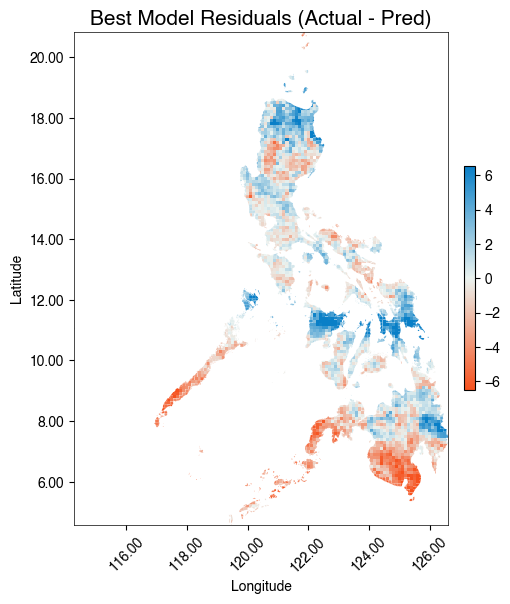

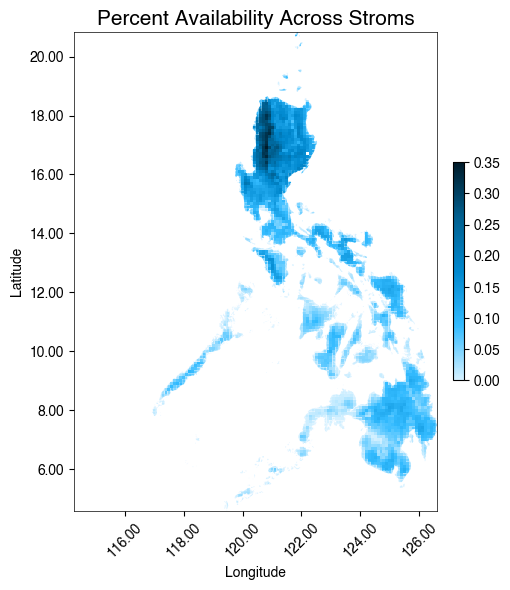

In [260]:
# lgbm_full_gdf

grid_point_avail_across_storm =  full_gdf.groupby('grid_point_id')['perc_available_upscaled_new'].mean()
grid_point_residuals_across_storm =  full_gdf.groupby('grid_point_id')['residuals'].mean()
grid_point_ground_truth_across_storm =  full_gdf.groupby('grid_point_id')['y_actual'].mean()
grid_point_predictions_across_storm =  full_gdf.groupby('grid_point_id')['y_pred'].mean()

#rest the column name to make easier to join and reset the index for merging
grid_point_avail_across_storm = grid_point_avail_across_storm.reset_index()
grid_point_residuals_across_storm = grid_point_residuals_across_storm.reset_index()
grid_point_ground_truth_across_storm = grid_point_ground_truth_across_storm.reset_index()
grid_point_predictions_across_storm = grid_point_predictions_across_storm.reset_index()


#join the geodata to these median values for plotting
grid_point_avail_across_storm_gdf = gdf.merge(grid_point_avail_across_storm, on='grid_point_id', how='right')
grid_point_residuals_across_storm_gdf = gdf.merge(grid_point_residuals_across_storm, on='grid_point_id', how='right')
grid_point_ground_truth_across_storm_gdf = gdf.merge(grid_point_ground_truth_across_storm, on='grid_point_id', how='right')
grid_point_predictions_across_storm_gdf = gdf.merge(grid_point_predictions_across_storm, on='grid_point_id', how='right')

#     print(storm)
#     print(grid_point_residuals_across_storm_test_storm.residuals.max(),
#           grid_point_residuals_across_storm_test_storm.residuals.min())

#     print(grid_point_ground_truth_across_storm_test_storm.y_actual.max(),
#           grid_point_ground_truth_across_storm_test_storm.y_actual.min())

cmap1 = mcolors.LinearSegmentedColormap.from_list(
    "my_cmap",
    ['#0088ce', '#7fb646', '#ee964b', '#87677b', '#26413c']
)

same_scale_color_map = mcolors.LinearSegmentedColormap.from_list(
    "my_cmap",
    ['#D6F1FF', '#33BBFF', '#0088ce', '#005F8F', '#001B29']
)
plt.rcParams['font.family'] = 'Helvetica'

try:
    fig, axes = plot_geodataframe_choropleth(
                grid_point_ground_truth_across_storm_gdf,
                'y_actual',
                same_scale_color_map,
                (5,9),
                'Actual Reported Damage',
                vmin=0.0,
                vmax=100.0,
                # edge_color: str = "none",
                # edge_width: float = 0.1,
                missing_color="white",
                diverging=False
            )
    figure_name = f"ground_truth_overall.jpeg"
    plt.savefig(f'../figures/synth_figures_for_results/{figure_name}')
    plt.show()

    fig, axes = plot_geodataframe_choropleth(
                grid_point_predictions_across_storm_gdf,
                'y_pred',
                same_scale_color_map,
                (5,9),
                'Best Model Predictions',
                vmin=0.0,
                vmax=100.0,
                # edge_color: str = "none",
                # edge_width: float = 0.1,
                missing_color="white",
                diverging=False
            )
    figure_name = f"y_pred_overall.jpeg"
    plt.savefig(f'../figures/synth_figures_for_results/{figure_name}')
    plt.show()

    fig, axes = plot_geodataframe_choropleth(
                grid_point_residuals_across_storm_gdf,
                'residuals',
                thesis_cmap_div,
                (5,9),
                'Best Model Residuals (Actual - Pred)',
                # vmin: float = None,
                # vmax: float = None,
                # edge_color: str = "none",
                # edge_width: float = 0.1,
                missing_color="white",
                diverging=True
            )
    figure_name = f"residuals_overall.jpeg"
    plt.savefig(f'../figures/synth_figures_for_results/{figure_name}')
    plt.show()

    fig, axes = plot_geodataframe_choropleth(
                grid_point_avail_across_storm_gdf,
                'perc_available_upscaled_new',
                same_scale_color_map,
                (5,9),
                'Percent Availability Across Stroms',
                vmin=0.0,
                vmax=0.35,
                # edge_color: str = "none",
                # edge_width: float = 0.1,
                missing_color="white",
                diverging=False
            )
    figure_name = f"availability_overall.jpeg"
    plt.savefig(f'../figures/synth_figures_for_results/{figure_name}')
    plt.show()
except Exception as e:
    print(f"Skipping {storm}: {e}") 
finally:
    pass

In [67]:
# bin wind speeds and look at damage rate per bin
target['wind_bin'] = pd.cut(target['wind_speed'], bins=range(0, 80, 5))
damage_rate = target.groupby('wind_bin', observed=True).agg(
    pct_with_damage=('percent_houses_damaged', lambda x: (x > 0).mean()),
    mean_damage=('percent_houses_damaged', 'mean'),
    count=('percent_houses_damaged', 'count')
).reset_index()

print(damage_rate)

    wind_bin  pct_with_damage  mean_damage  count
0     (0, 5]         0.022269     0.001123    943
1    (5, 10]         0.074004     0.012486   5824
2   (10, 15]         0.072526     0.036214  12368
3   (15, 20]         0.095054     0.026743  10352
4   (20, 25]         0.166882     0.095115   6202
5   (25, 30]         0.288110     0.197262   3936
6   (30, 35]         0.395992     0.606430   2894
7   (35, 40]         0.585062     0.976351   2169
8   (40, 45]         0.736242     2.063993   2017
9   (45, 50]         0.813788     3.221661   1262
10  (50, 55]         0.858378     6.818437    925
11  (55, 60]         0.941452    15.311720    427
12  (60, 65]         0.932773    24.870863    238
13  (65, 70]         0.950704    36.972762    142
14  (70, 75]         1.000000    58.254511     55


/var/folders/xw/1pm761sd11b96_3c77wx1b900000gn/T/ipykernel_35976/3904992520.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


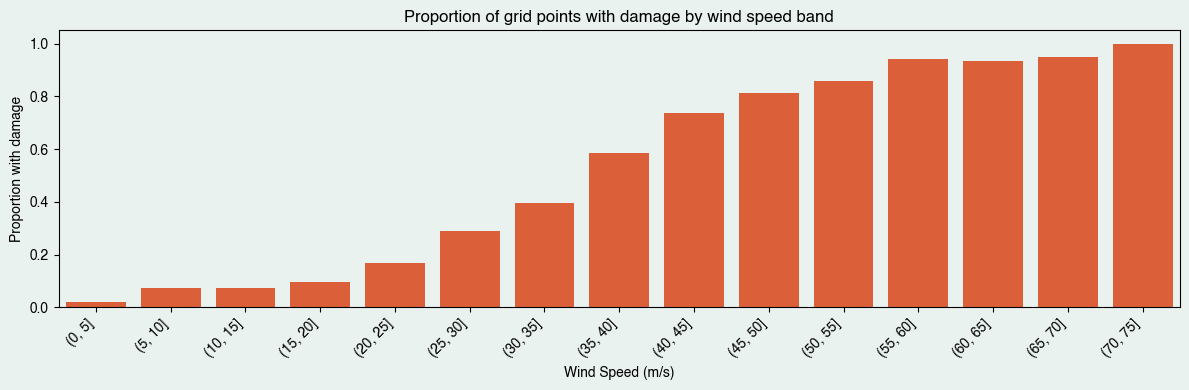

In [70]:
fig, ax = plt.subplots(figsize=(12, 4), facecolor=BACKGROUND_COLOR)
ax.set_facecolor(BACKGROUND_COLOR)

sns.barplot(
    data=damage_rate,
    x='wind_bin',
    y='pct_with_damage',
    color='#F6511D',
    ax=ax
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title('Proportion of grid points with damage by wind speed band')
ax.set_xlabel('Wind Speed (m/s)')
ax.set_ylabel('Proportion with damage')

plt.tight_layout()
plt.show()

In [78]:
v_thresh = 25
v_half = 35

# Emanuel (2011) impact function
wind_damage = target['wind_speed']**3 / (target['wind_speed']**3 + v_half**3)
wind_damage[target['wind_speed'] < v_thresh] = 0

proxy = wind_damage  # 0-1 range by definition of the sigmoidal function


# scale proxy to match mean and std of actual non-zero damage
nonzero_mean = target[target['percent_houses_damaged'] > 0]['percent_houses_damaged'].mean()
nonzero_std  = target[target['percent_houses_damaged'] > 0]['percent_houses_damaged'].std()

proxy_norm = (proxy - proxy.min()) / (proxy.max() - proxy.min())  # 0-1
proxy_scaled = proxy_norm * nonzero_std + nonzero_mean  # shift to match observed scale

# sanity check
print(f"Proxy range: {proxy_scaled.min():.2f} – {proxy_scaled.max():.2f}")
print(f"Actual non-zero range: {target[target['percent_houses_damaged'] > 0]['percent_houses_damaged'].min():.2f} – {target[target['percent_houses_damaged'] > 0]['percent_houses_damaged'].max():.2f}")
print(f"Proxy mean: {proxy_scaled.mean():.2f} vs actual mean: {nonzero_mean:.2f}")

Proxy range: 3.56 – 13.73
Actual non-zero range: 0.00 – 251.47
Proxy mean: 4.15 vs actual mean: 3.56


In [113]:
print(f"actual_99: {actual_99:.2f}")
print(f"actual max: {target['percent_houses_damaged'].max():.2f}")
print(f"actual mean non-zero: {target[target['percent_houses_damaged'] > 0]['percent_houses_damaged'].mean():.2f}")

actual_99: 6.98
actual max: 251.47
actual mean non-zero: 3.56


In [ ]:
# option 1 — anchor to 99.9th percentile
actual_anchor = target['percent_houses_damaged'].quantile(0.999)

# option 2 — anchor to actual max
actual_anchor = target['percent_houses_damaged'].max()

# option 3 — scale to match non-zero mean and std
nonzero_mean = target[target['percent_houses_damaged'] > 0]['percent_houses_damaged'].mean()
nonzero_std  = target[target['percent_houses_damaged'] > 0]['percent_houses_damaged'].std()
proxy_scaled[nonzero_mask] = proxy_norm * nonzero_std * 3 + nonzero_mean  # *3 to get right tail